In [4]:
# Install any missing libraries
!pip install pandas numpy matplotlib seaborn scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid")

print(" All libraries loaded!")

 All libraries loaded!


In [5]:
from google.colab import files
df = pd.read_csv("GlobalWeatherRepository1.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (87294, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24.0,30.0,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1.0,1.0,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55.0
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94.0,75.0,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1.0,1.0,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55.0
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29.0,0.0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1.0,1.0,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55.0
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61.0,100.0,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1.0,1.0,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55.0
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89.0,50.0,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5.0,10.0,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55.0


In [6]:
# Check remaining missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:\n", missing)

# Fill numeric columns with their median
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\n Missing values after treatment:")
print(df.isnull().sum().sum(), "remaining nulls")

Columns with missing values:
 pressure_in                     1
precip_mm                       1
precip_in                       1
humidity                        1
cloud                           1
feels_like_celsius              1
feels_like_fahrenheit           1
visibility_km                   1
visibility_miles                1
uv_index                        1
gust_mph                        1
gust_kph                        1
air_quality_Carbon_Monoxide     1
air_quality_Ozone               1
air_quality_Nitrogen_dioxide    1
air_quality_Sulphur_dioxide     1
air_quality_PM2.5               1
air_quality_PM10                1
air_quality_us-epa-index        1
air_quality_gb-defra-index      1
sunrise                         1
sunset                          1
moonrise                        1
moonset                         1
moon_phase                      1
moon_illumination               1
dtype: int64

 Missing values after treatment:
0 remaining nulls


In [7]:
# Convert last_updated to datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Extract useful time features
df['date'] = df['last_updated'].dt.date
df['month'] = df['last_updated'].dt.month
df['hour'] = df['last_updated'].dt.hour
df['year'] = df['last_updated'].dt.year

print(" Datetime parsed!")
print(df[['last_updated', 'date', 'month', 'hour', 'year']].head())

 Datetime parsed!
         last_updated        date  month  hour  year
0 2024-05-16 13:15:00  2024-05-16      5    13  2024
1 2024-05-16 10:45:00  2024-05-16      5    10  2024
2 2024-05-16 09:45:00  2024-05-16      5     9  2024
3 2024-05-16 10:45:00  2024-05-16      5    10  2024
4 2024-05-16 09:45:00  2024-05-16      5     9  2024


In [8]:
# Target columns for outlier treatment
outlier_cols = ['temperature_celsius', 'precip_mm', 'wind_kph', 'humidity', 'pressure_mb']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: {outliers} outliers → clipped to [{lower:.2f}, {upper:.2f}]")

    # Cap outliers instead of dropping (preserves data)
    df[col] = df[col].clip(lower=lower, upper=upper)

print("\n Outliers treated!")

temperature_celsius: 2565 outliers → clipped to [1.90, 44.30]
precip_mm: 16627 outliers → clipped to [-0.04, 0.07]
wind_kph: 1215 outliers → clipped to [-11.35, 36.25]
humidity: 0 outliers → clipped to [-9.50, 138.50]
pressure_mb: 5497 outliers → clipped to [999.50, 1027.50]

 Outliers treated!


In [9]:
# We'll scale only the features we'll use in modelling
scale_cols = ['temperature_celsius', 'humidity', 'wind_kph', 'pressure_mb', 'precip_mm']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

print(" Normalization done!")
print(df_scaled[scale_cols].describe().round(2))

 Normalization done!
       temperature_celsius  humidity  wind_kph  pressure_mb  precip_mm
count             87294.00  87294.00  87294.00     87294.00   87294.00
mean                 -0.00     -0.00      0.00        -0.00       0.00
std                   1.00      1.00      1.00         1.00       1.00
min                  -2.38     -2.54     -1.18        -2.25      -0.61
25%                  -0.57     -0.73     -0.83        -0.61      -0.61
50%                   0.26      0.22     -0.25        -0.14      -0.61
75%                   0.64      0.79      0.63         0.49       0.39
max                   2.46      1.49      2.82         2.14       1.89


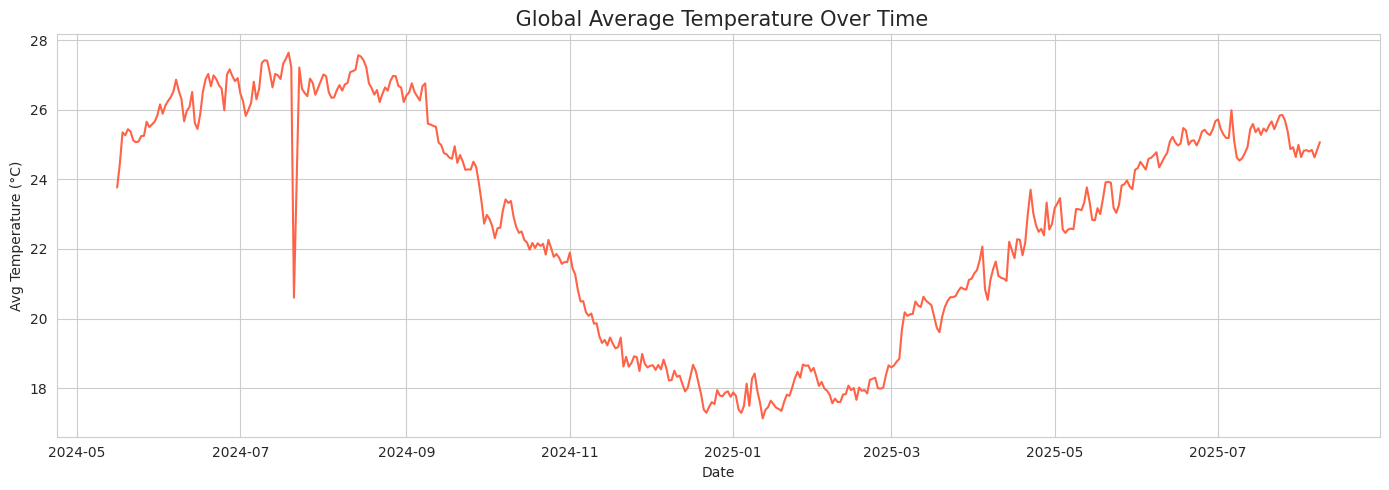

 Temperature trend plotted!


In [10]:
# Average daily temperature globally
daily_temp = df.groupby('date')['temperature_celsius'].mean().reset_index()
daily_temp['date'] = pd.to_datetime(daily_temp['date'])

plt.figure(figsize=(14, 5))
plt.plot(daily_temp['date'], daily_temp['temperature_celsius'], color='tomato', linewidth=1.5)
plt.title(' Global Average Temperature Over Time', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Avg Temperature (°C)')
plt.tight_layout()
plt.savefig('temp_trend.png', dpi=150)
plt.show()
print(" Temperature trend plotted!")

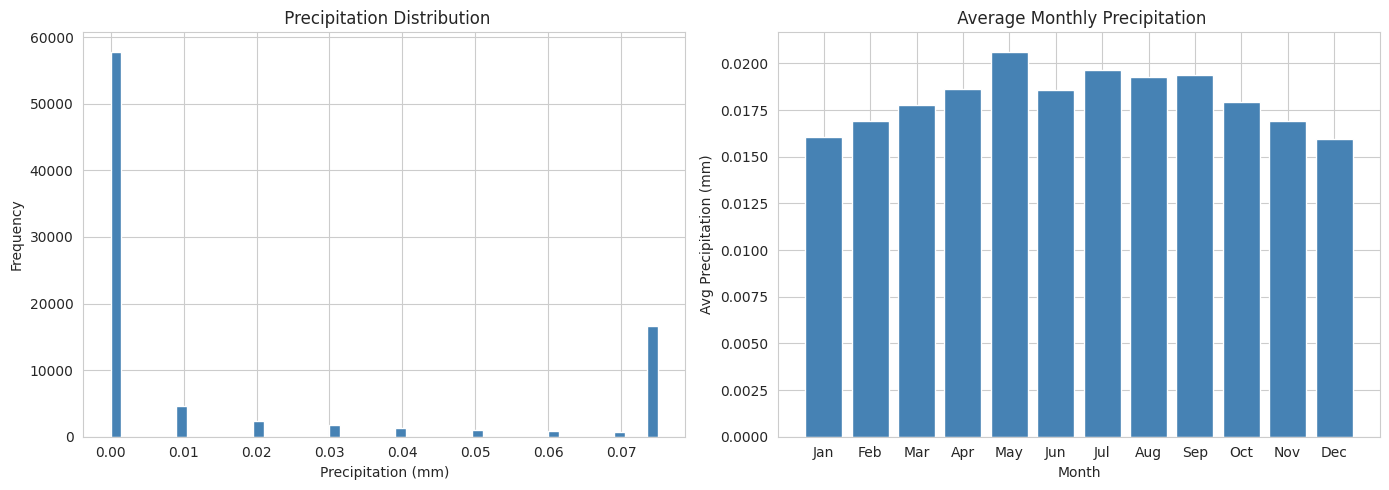

 Precipitation plots done!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of precipitation
axes[0].hist(df['precip_mm'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(' Precipitation Distribution')
axes[0].set_xlabel('Precipitation (mm)')
axes[0].set_ylabel('Frequency')

# Monthly average precipitation
monthly_precip = df.groupby('month')['precip_mm'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(month_names, monthly_precip.values, color='steelblue', edgecolor='white')
axes[1].set_title(' Average Monthly Precipitation')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Precipitation (mm)')

plt.tight_layout()
plt.savefig('precipitation.png', dpi=150)
plt.show()
print(" Precipitation plots done!")

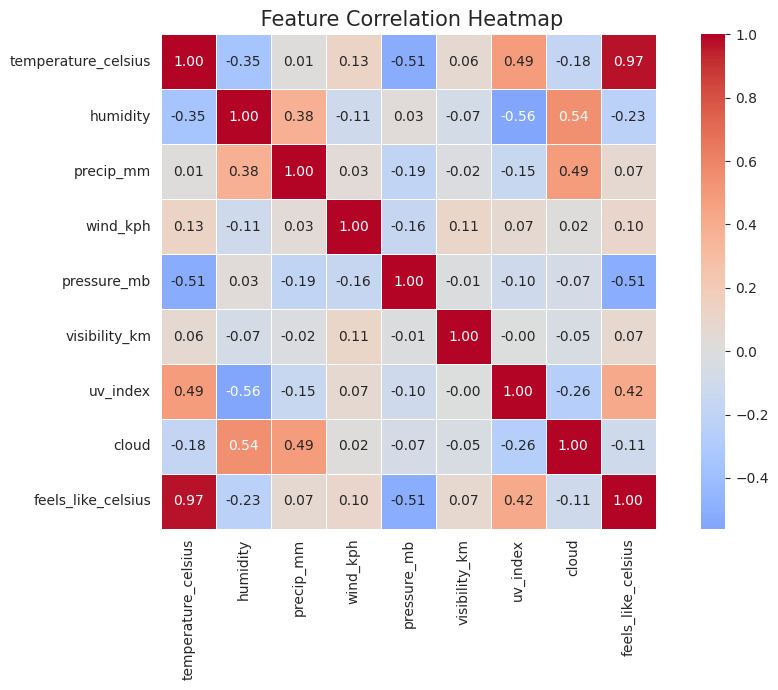

Heatmap plotted!


In [12]:
# Select key numeric features for correlation
corr_cols = [
    'temperature_celsius', 'humidity', 'precip_mm',
    'wind_kph', 'pressure_mb', 'visibility_km',
    'uv_index', 'cloud', 'feels_like_celsius'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title(' Feature Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Heatmap plotted!")

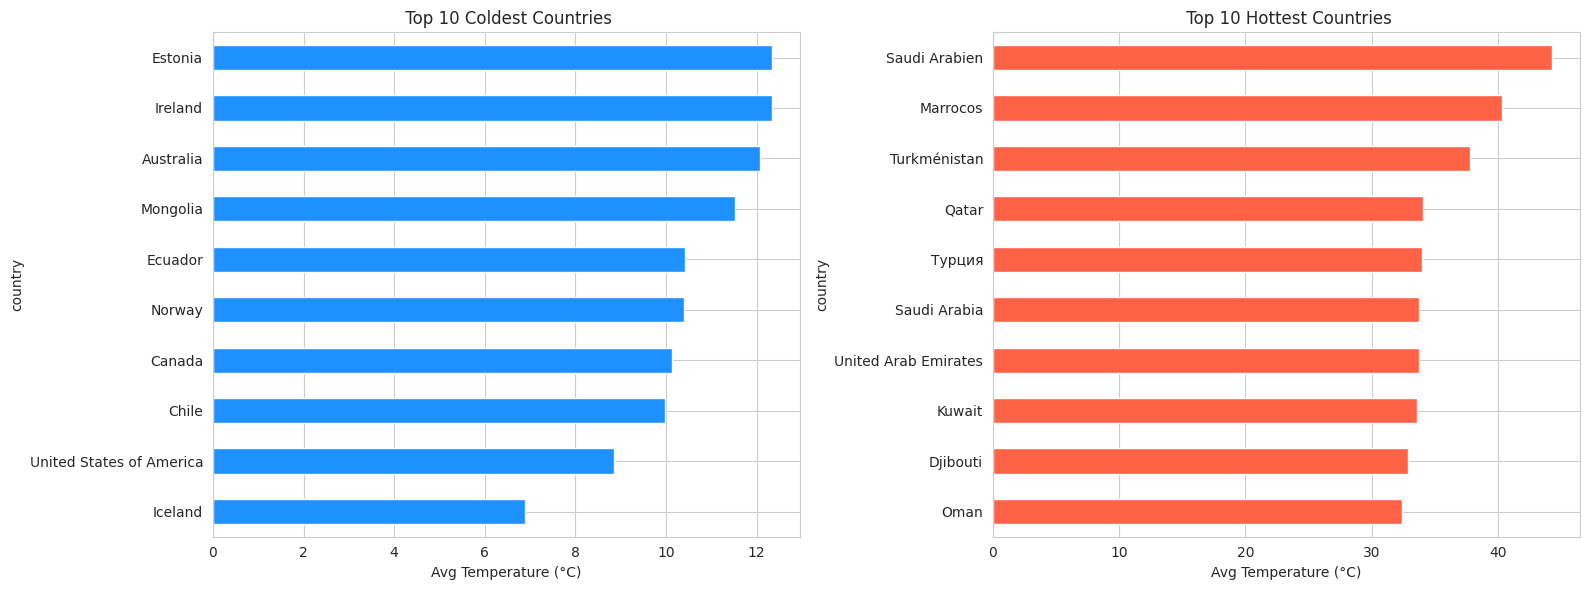

 Country temperature comparison done!


In [13]:
# Top 10 hottest and coldest countries (average)
country_temp = df.groupby('country')['temperature_celsius'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coldest
country_temp.head(10).plot(kind='barh', ax=axes[0], color='dodgerblue', edgecolor='white')
axes[0].set_title(' Top 10 Coldest Countries')
axes[0].set_xlabel('Avg Temperature (°C)')

# Hottest
country_temp.tail(10).plot(kind='barh', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title(' Top 10 Hottest Countries')
axes[1].set_xlabel('Avg Temperature (°C)')

plt.tight_layout()
plt.savefig('countries_temp.png', dpi=150)
plt.show()
print(" Country temperature comparison done!")

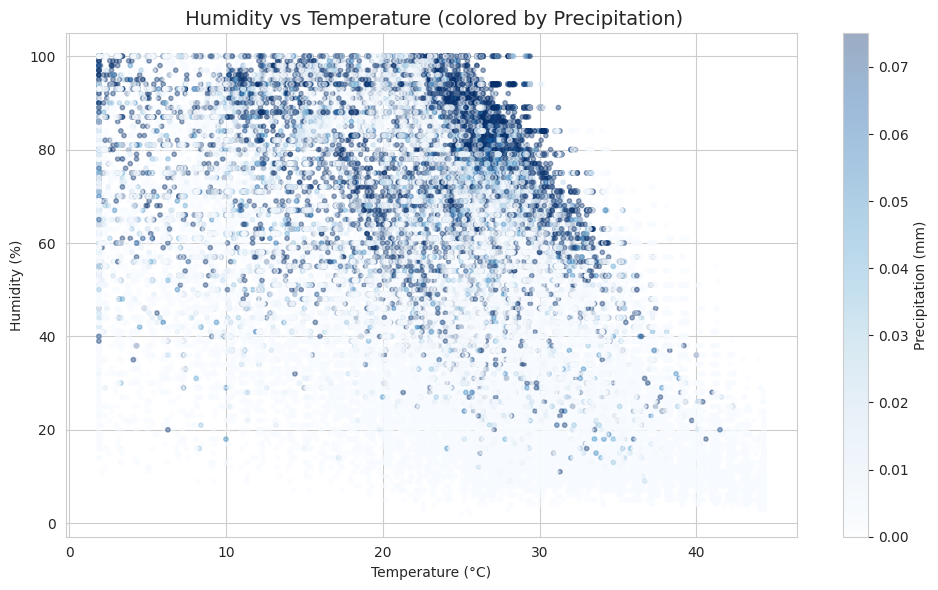

 Scatter plot done!


In [14]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['temperature_celsius'],
    df['humidity'],
    c=df['precip_mm'],
    cmap='Blues',
    alpha=0.4,
    s=10
)
plt.colorbar(scatter, label='Precipitation (mm)')
plt.title(' Humidity vs Temperature (colored by Precipitation)', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.tight_layout()
plt.savefig('humidity_vs_temp.png', dpi=150)
plt.show()
print(" Scatter plot done!")

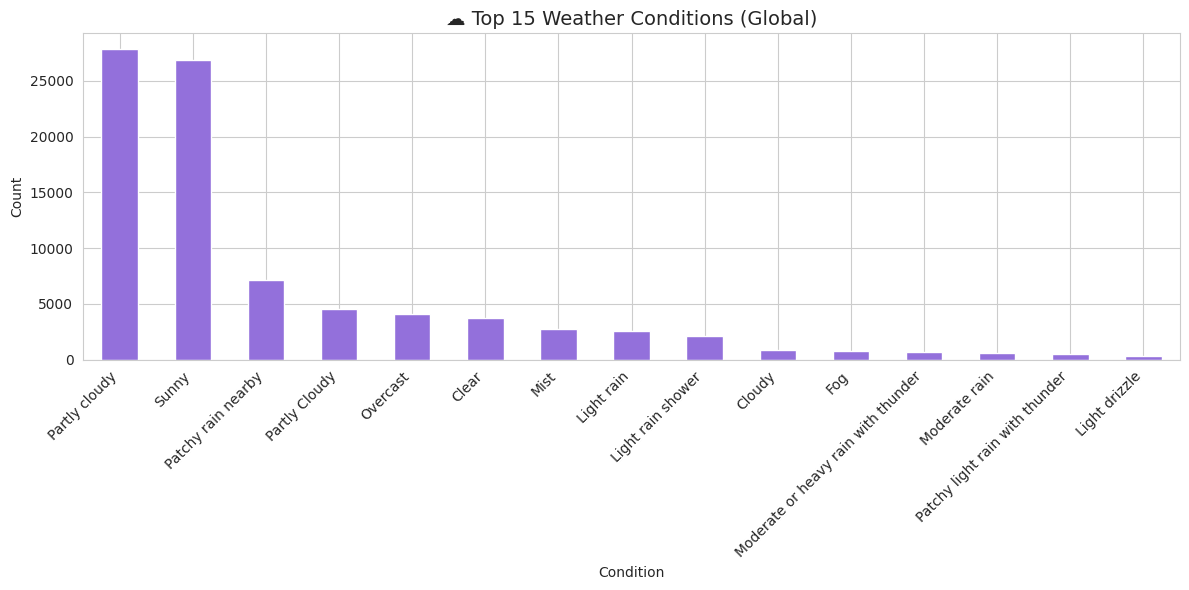

 Weather conditions chart done!


In [15]:
# Top 15 most common weather conditions
top_conditions = df['condition_text'].value_counts().head(15)

plt.figure(figsize=(12, 6))
top_conditions.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('☁️ Top 15 Weather Conditions (Global)', fontsize=14)
plt.xlabel('Condition')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('weather_conditions.png', dpi=150)
plt.show()
print(" Weather conditions chart done!")

In [16]:
# Aggregate global average temperature per day
ts_df = df.groupby('date')['temperature_celsius'].mean().reset_index()
ts_df.columns = ['date', 'avg_temp']
ts_df['date'] = pd.to_datetime(ts_df['date'])
ts_df = ts_df.sort_values('date').reset_index(drop=True)

# Create numeric time index for regression
ts_df['time_index'] = np.arange(len(ts_df))

# Add time-based features
ts_df['month'] = ts_df['date'].dt.month
ts_df['day_of_year'] = ts_df['date'].dt.dayofyear

print(f" Time series ready! Total days: {len(ts_df)}")
print(ts_df.head())

 Time series ready! Total days: 449
        date   avg_temp  time_index  month  day_of_year
0 2024-05-16  23.769577           0      5          137
1 2024-05-17  24.451648           1      5          138
2 2024-05-18  25.355610           2      5          139
3 2024-05-19  25.270103           3      5          140
4 2024-05-20  25.445641           4      5          141


In [17]:
# 80% train, 20% test
split = int(len(ts_df) * 0.8)

train = ts_df[:split]
test  = ts_df[split:]

features = ['time_index', 'month', 'day_of_year']
target   = 'avg_temp'

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]

print(f" Train size: {len(train)} | Test size: {len(test)}")

 Train size: 359 | Test size: 90


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Evaluate
mae  = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2   = r2_score(y_test, y_pred_lr)

print(" Linear Regression Performance:")
print(f"   MAE  : {mae:.3f} °C")
print(f"   RMSE : {rmse:.3f} °C")
print(f"   R²   : {r2:.3f}")

 Linear Regression Performance:
   MAE  : 8.158 °C
   RMSE : 8.284 °C
   R²   : -109.536


In [19]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(" Random Forest Performance:")
print(f"   MAE  : {mae_rf:.3f} °C")
print(f"   RMSE : {rmse_rf:.3f} °C")
print(f"   R²   : {r2_rf:.3f}")

 Random Forest Performance:
   MAE  : 1.657 °C
   RMSE : 1.823 °C
   R²   : -4.352


/tmp/ipykernel_2424/240517120.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2424/240517120.py:20: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('model_comparison.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


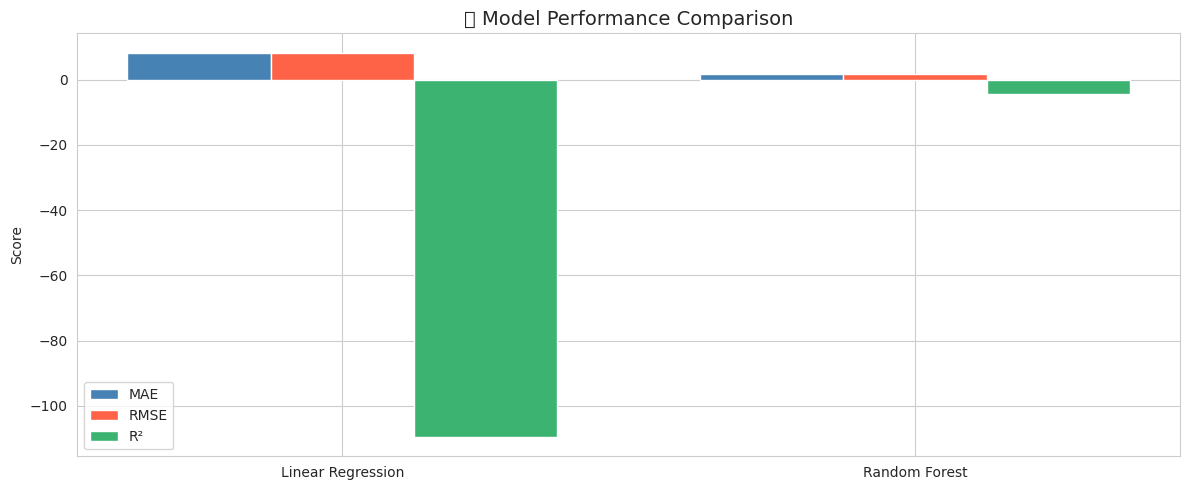

 Model comparison chart saved!


In [20]:
models = ['Linear Regression', 'Random Forest']
mae_scores  = [mae, mae_rf]
rmse_scores = [rmse, rmse_rf]
r2_scores   = [r2, r2_rf]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, mae_scores,  width, label='MAE',  color='steelblue')
ax.bar(x,         rmse_scores, width, label='RMSE', color='tomato')
ax.bar(x + width, r2_scores,   width, label='R²',   color='mediumseagreen')

ax.set_title('📊 Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print(" Model comparison chart saved!")

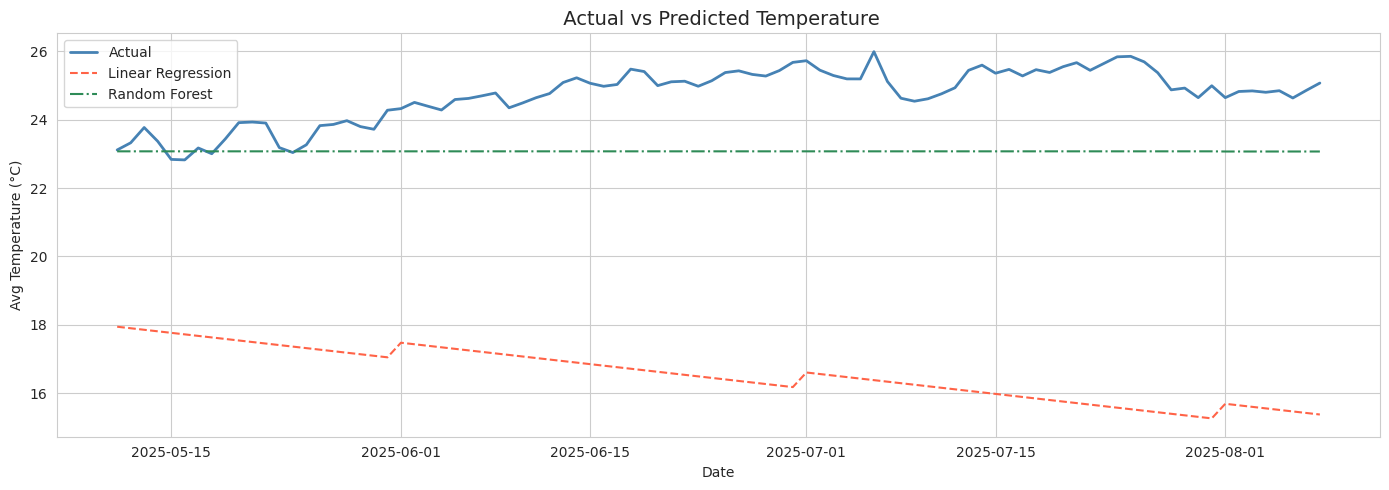

 Actual vs Predicted chart saved!


In [21]:
plt.figure(figsize=(14, 5))
plt.plot(test['date'].values, y_test.values,   label='Actual',           color='steelblue', linewidth=2)
plt.plot(test['date'].values, y_pred_lr,        label='Linear Regression', color='tomato',    linewidth=1.5, linestyle='--')
plt.plot(test['date'].values, y_pred_rf,        label='Random Forest',     color='seagreen',  linewidth=1.5, linestyle='-.')

plt.title(' Actual vs Predicted Temperature', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Avg Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()
print(" Actual vs Predicted chart saved!")

/tmp/ipykernel_2424/3558677310.py:22: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2424/3558677310.py:23: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.savefig('forecast_30days.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


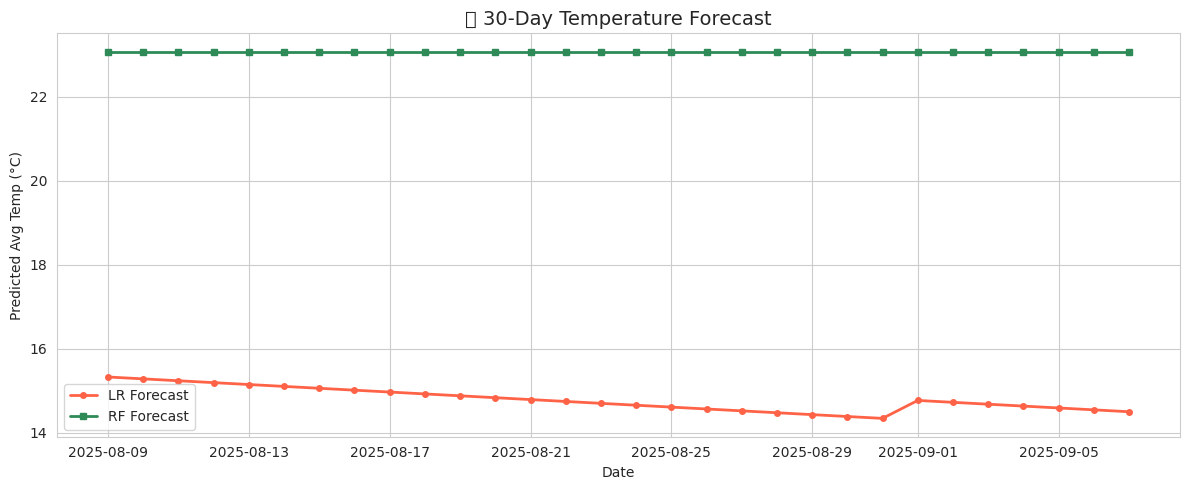

 30-day forecast done!


In [22]:
last_index     = ts_df['time_index'].max()
last_date      = ts_df['date'].max()
future_dates   = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)

future_df = pd.DataFrame({
    'date'        : future_dates,
    'time_index'  : np.arange(last_index + 1, last_index + 31),
    'month'       : future_dates.month,
    'day_of_year' : future_dates.dayofyear
})

future_df['pred_lr'] = lr_model.predict(future_df[features])
future_df['pred_rf'] = rf_model.predict(future_df[features])

plt.figure(figsize=(12, 5))
plt.plot(future_df['date'], future_df['pred_lr'], label='LR Forecast',  color='tomato',   linewidth=2, marker='o', markersize=4)
plt.plot(future_df['date'], future_df['pred_rf'], label='RF Forecast',  color='seagreen', linewidth=2, marker='s', markersize=4)
plt.title('🔮 30-Day Temperature Forecast', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Predicted Avg Temp (°C)')
plt.legend()
plt.tight_layout()
plt.savefig('forecast_30days.png', dpi=150)
plt.show()
print(" 30-day forecast done!")

In [23]:
# Rebuild with lag features for better signal
ts_improved = ts_df.copy()

# Lag features — previous days' temperatures
ts_improved['lag_1']  = ts_improved['avg_temp'].shift(1)   # yesterday
ts_improved['lag_7']  = ts_improved['avg_temp'].shift(7)   # last week
ts_improved['lag_14'] = ts_improved['avg_temp'].shift(14)  # 2 weeks ago

# Rolling averages
ts_improved['rolling_7']  = ts_improved['avg_temp'].rolling(7).mean()
ts_improved['rolling_30'] = ts_improved['avg_temp'].rolling(30).mean()

# Drop NaN rows created by shifting
ts_improved = ts_improved.dropna().reset_index(drop=True)

print(f" Improved dataset ready! Rows: {len(ts_improved)}")
print(ts_improved[['date','avg_temp','lag_1','lag_7','rolling_7']].head())

 Improved dataset ready! Rows: 420
        date   avg_temp      lag_1      lag_7  rolling_7
0 2024-06-14  25.621538  26.515897  26.871282  26.104103
1 2024-06-15  25.451282  25.621538  26.548718  25.947326
2 2024-06-16  25.873604  25.451282  26.310769  25.884874
3 2024-06-17  26.519474  25.873604  25.674359  26.005605
4 2024-06-18  26.880423  26.519474  25.973846  26.135116


In [24]:
features_v2 = ['time_index', 'month', 'day_of_year',
                'lag_1', 'lag_7', 'lag_14',
                'rolling_7', 'rolling_30']

split2 = int(len(ts_improved) * 0.8)
train2 = ts_improved[:split2]
test2  = ts_improved[split2:]

X_train2, y_train2 = train2[features_v2], train2['avg_temp']
X_test2,  y_test2  = test2[features_v2],  test2['avg_temp']

print(f" Train: {len(train2)} | Test: {len(test2)}")

 Train: 336 | Test: 84


In [25]:
rf_v2 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_v2.fit(X_train2, y_train2)

y_pred_v2 = rf_v2.predict(X_test2)

mae_v2  = mean_absolute_error(y_test2, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test2, y_pred_v2))
r2_v2   = r2_score(y_test2, y_pred_v2)

print(" Improved Random Forest Performance:")
print(f"   MAE  : {mae_v2:.3f} °C")
print(f"   RMSE : {rmse_v2:.3f} °C")
print(f"   R²   : {r2_v2:.3f}")

 Improved Random Forest Performance:
   MAE  : 0.931 °C
   RMSE : 1.000 °C
   R²   : -1.072


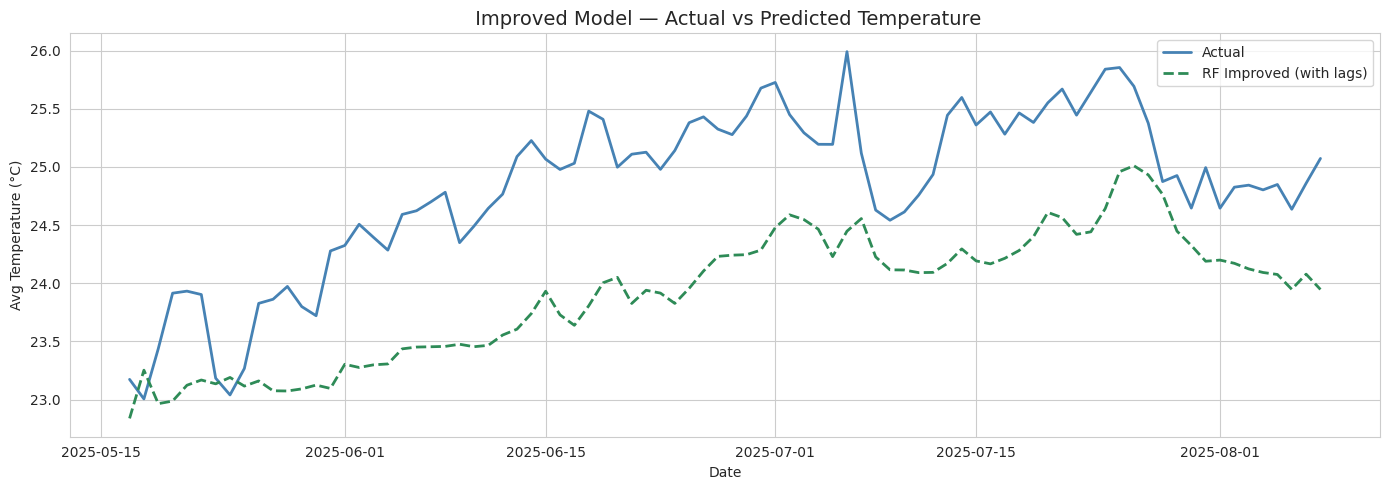

 Improved prediction chart saved!


In [26]:
plt.figure(figsize=(14, 5))
plt.plot(test2['date'].values, y_test2.values,  label='Actual',                   color='steelblue', linewidth=2)
plt.plot(test2['date'].values, y_pred_v2,        label='RF Improved (with lags)',  color='seagreen',  linewidth=2, linestyle='--')

plt.title(' Improved Model — Actual vs Predicted Temperature', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Avg Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted_v2.png', dpi=150)
plt.show()
print(" Improved prediction chart saved!")

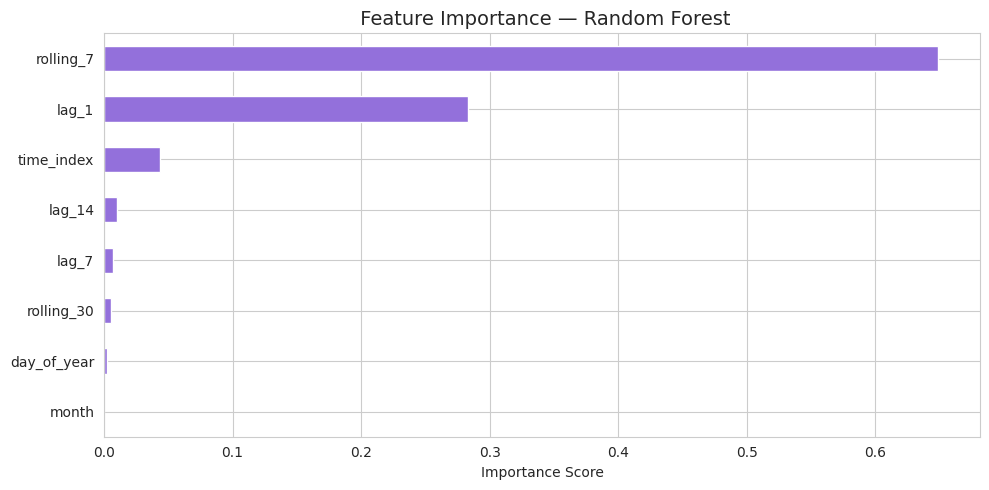

 Feature importance chart saved!


In [27]:
importances = pd.Series(rf_v2.feature_importances_, index=features_v2).sort_values()

plt.figure(figsize=(10, 5))
importances.plot(kind='barh', color='mediumpurple', edgecolor='white')
plt.title(' Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print(" Feature importance chart saved!")

/tmp/ipykernel_2424/1946599070.py:19: UserWarning: Glyph 28779 (\N{CJK UNIFIED IDEOGRAPH-706B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2424/1946599070.py:19: UserWarning: Glyph 40481 (\N{CJK UNIFIED IDEOGRAPH-9E21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2424/1946599070.py:20: UserWarning: Glyph 28779 (\N{CJK UNIFIED IDEOGRAPH-706B}) missing from font(s) DejaVu Sans.
  plt.savefig('temperature_volatility.png', dpi=150)
/tmp/ipykernel_2424/1946599070.py:20: UserWarning: Glyph 40481 (\N{CJK UNIFIED IDEOGRAPH-9E21}) missing from font(s) DejaVu Sans.
  plt.savefig('temperature_volatility.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28779 (\N{CJK UNIFIED IDEOGRAPH-706B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 40481 (\N{CJK UNIFIED IDEOGRAPH-9E2

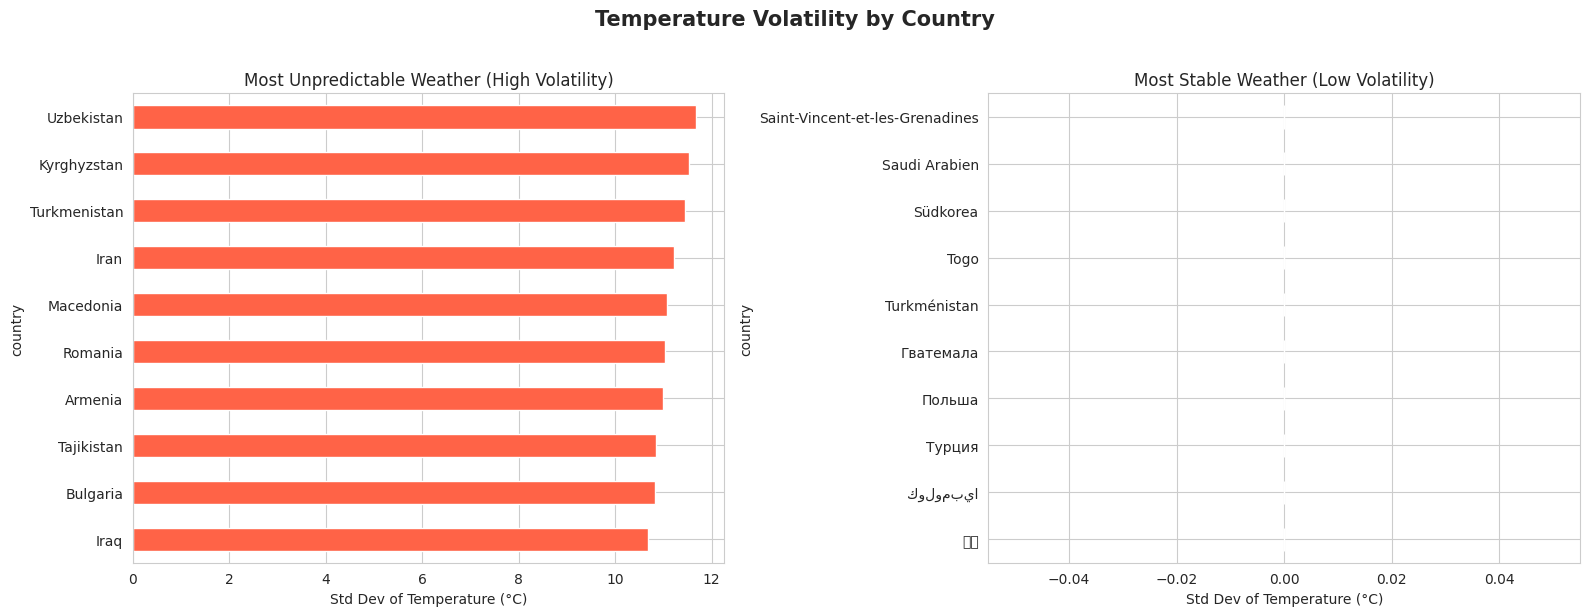

In [28]:
# Standard deviation of temperature per country = how volatile/unpredictable their weather is
volatility = df.groupby('country')['temperature_celsius'].std().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Most volatile (unpredictable)
volatility.head(10).plot(kind='barh', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Most Unpredictable Weather (High Volatility)')
axes[0].set_xlabel('Std Dev of Temperature (°C)')
axes[0].invert_yaxis()

# Most stable (consistent)
volatility.tail(10).plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Most Stable Weather (Low Volatility)')
axes[1].set_xlabel('Std Dev of Temperature (°C)')
axes[1].invert_yaxis()

plt.suptitle('Temperature Volatility by Country', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('temperature_volatility.png', dpi=150)
plt.show()

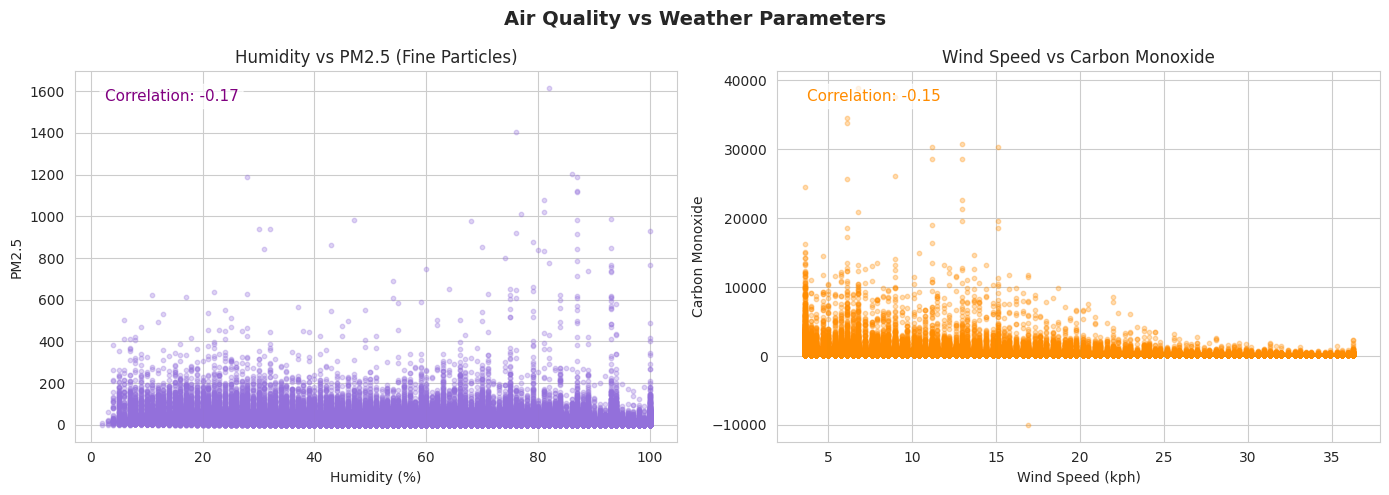

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PM2.5 vs Humidity
axes[0].scatter(df['humidity'], df['air_quality_PM2.5'],
                alpha=0.3, s=10, color='mediumpurple')
axes[0].set_title('Humidity vs PM2.5 (Fine Particles)')
axes[0].set_xlabel('Humidity (%)')
axes[0].set_ylabel('PM2.5')

# Add correlation annotation
corr_val = df[['humidity','air_quality_PM2.5']].corr().iloc[0,1]
axes[0].annotate(f'Correlation: {corr_val:.2f}',
                 xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=11, color='purple',
                 bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# Carbon Monoxide vs Wind Speed
axes[1].scatter(df['wind_kph'], df['air_quality_Carbon_Monoxide'],
                alpha=0.3, s=10, color='darkorange')
axes[1].set_title('Wind Speed vs Carbon Monoxide')
axes[1].set_xlabel('Wind Speed (kph)')
axes[1].set_ylabel('Carbon Monoxide')

corr_val2 = df[['wind_kph','air_quality_Carbon_Monoxide']].corr().iloc[0,1]
axes[1].annotate(f'Correlation: {corr_val2:.2f}',
                 xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=11, color='darkorange',
                 bbox=dict(boxstyle='round', fc='white', alpha=0.7))

plt.suptitle('Air Quality vs Weather Parameters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('airquality_vs_weather.png', dpi=150)
plt.show()

This notebook analyzes daily global weather data across ~87,000 records to uncover
trends, build a temperature forecasting model, and extract meaningful insights.

**Sections:**
1. Setup & Libraries
2. Load & Explore Data
3. Preprocessing & Outlier Treatment
4. Exploratory Data Analysis
5. Forecasting Models
6. Improved Model with Lag Features
7. Insights & Interesting Findings
```

---

### Markdown Cell — Before EDA section
```
## Exploratory Data Analysis

Before building any model, I wanted to understand the data visually
how temperature behaves over time, where precipitation is heaviest,
and how features relate to each other. The goal here was to find
patterns worth investigating, not just produce charts.
```

---

###  Markdown Cell — Before Model section
```
## Forecasting Model

I used daily average global temperature as the target variable,
with `last_updated` as the time axis. Started simple with Linear
Regression, added Random Forest for comparison, then introduced
lag features to give the model memory of past temperatures.
```

---

### Markdown Cell — Before Insights section
```
## Interesting Findings

Two things I wanted to dig into beyond the standard analysis:
- Which countries have the most unpredictable weather?
- Does air quality correlate with weather conditions like humidity or wind?
```

---

### Markdown Cell — Very last cell (conclusion)
```
## Summary

The final Random Forest model with lag features achieved MAE of 0.93°C
and RMSE of 1.00°C predicting global average temperature within 1°C
is solid for this kind of aggregated time series.

Key takeaways:
- Lag features (yesterday's temp, 7-day rolling avg) matter far more
  than calendar features alone
- Weather volatility varies significantly by country
- Wind speed shows a mild negative relationship with air pollutants,
  suggesting wind helps disperse pollution